# Data Pipeline

🎯 **Goal**: Produce clean train/val/test metadata tables from the original dataset files.

Approach:

- Assemble a clean modelling dataset from the CUB-200-2011 metadata
- Preserve the official train/test split
- Create a validation split from training only
- Verify that the data is ready for baseline modelling

### Imports

In [ ]:
from pathlib import Path

import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

## Load metadata

In [3]:
DATA_DIR = Path("../data/CUB_200_2011/CUB_200_2011")

In [4]:
# Mapping files to image paths
images = pd.read_csv(DATA_DIR / "images.txt", sep=" ", header=None, names=["image_id", "image_path"])

# Mapping files to class labels
labels = pd.read_csv(DATA_DIR / "image_class_labels.txt", sep=" ", header=None, names=["image_id", "class_id"])

# Maps class labels to class names
class_names = pd.read_csv(DATA_DIR / "classes.txt", sep=" ", header=None, names=["class_id", "class_name"])

# Mapping files to train/test split
split = pd.read_csv(DATA_DIR / "train_test_split.txt", sep=" ", header=None, names=["image_id", "is_training_image"])

In [5]:
# Merge metadata into a single DataFrame
metadata = (
    images
    .merge(labels, on="image_id")
    .merge(class_names, on="class_id")
    .merge(split, on="image_id")
)

In [7]:
metadata["image_path"].iloc[0]

'001.Black_footed_Albatross/Black_Footed_Albatross_0046_18.jpg'

In [8]:
# Add full class file paths from image paths
metadata["file_path"] = metadata["image_path"].apply(lambda x: DATA_DIR / "images" / x)

# Translate binary train/test column to string labels
metadata["split"] = metadata["is_training_image"].apply(lambda x: "train" if x == 1 else "test")

metadata.head()

,image_id,image_path,class_id,class_name,is_training_image,file_path,split
0,1,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross,0,../data/CUB_200_2011/CUB_200_2011/images/001.B...,test
1,2,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross,1,../data/CUB_200_2011/CUB_200_2011/images/001.B...,train
2,3,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross,0,../data/CUB_200_2011/CUB_200_2011/images/001.B...,test
3,4,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross,1,../data/CUB_200_2011/CUB_200_2011/images/001.B...,train
4,5,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross,1,../data/CUB_200_2011/CUB_200_2011/images/001.B...,train


In [9]:
# ---- Quick check on metadata ----

# total rows (should be ~11,788)
print("Total images:", len(metadata))

# number of classes (should be 200)
print("Unique classes:", metadata["class_id"].nunique())

# split distribution
print(metadata["split"].value_counts())

# check paths exist (sample)
from pathlib import Path
print(all(Path(p).exists() for p in metadata["file_path"].sample(20)))

Total images: 11788
Unique classes: 200
split
train    5994
test     5794
Name: count, dtype: int64
True


## Train test split

In [ ]:
# Separate train/test splits
train_df = metadata[metadata["split"] == "train"].copy()
test_df = metadata[metadata["split"] == "test"].copy()

# Create validation split from training data
train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["class_id"], # keep class balance
    random_state=42
)

print(len(train_df), len(val_df), len(test_df))

4795 1199 5794


In [14]:
# ---- Final checks on splits ----

# all splits should still have 200 classes
print(train_df["class_id"].nunique())
print(val_df["class_id"].nunique())
print(test_df["class_id"].nunique())

# quick look
train_df.sample(5)[["file_path", "class_name"]]

200
200
200


,file_path,class_name
4320,../data/CUB_200_2011/CUB_200_2011/images/075.G...,075.Green_Jay
2947,../data/CUB_200_2011/CUB_200_2011/images/051.H...,051.Horned_Grebe
9664,../data/CUB_200_2011/CUB_200_2011/images/165.C...,165.Chestnut_sided_Warbler
1989,../data/CUB_200_2011/CUB_200_2011/images/035.P...,035.Purple_Finch
1585,../data/CUB_200_2011/CUB_200_2011/images/029.A...,029.American_Crow


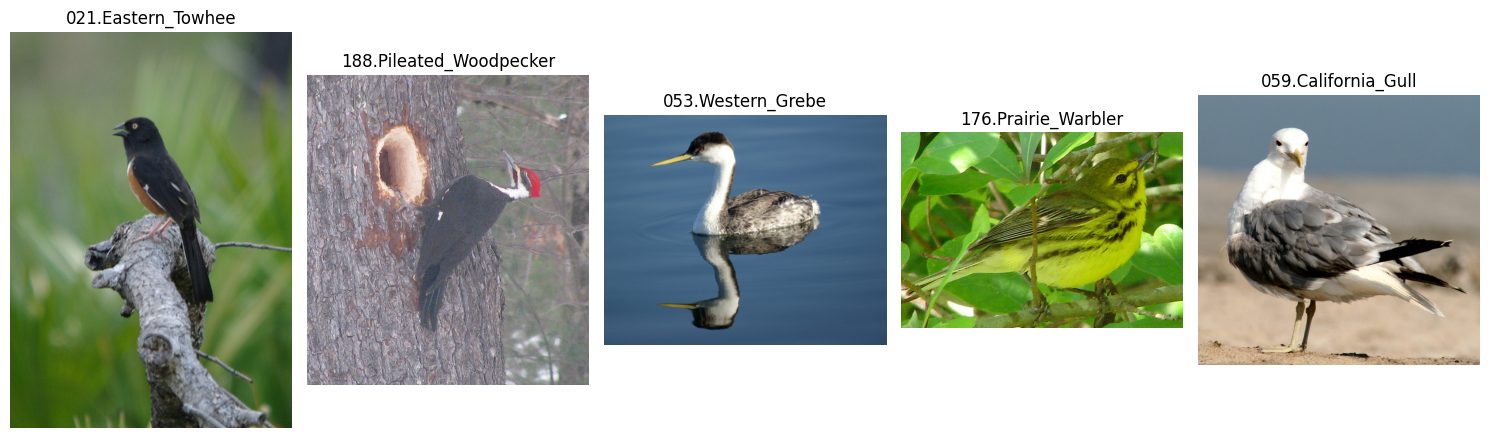

In [ ]:
# ---- Quick visual check ----

# sample 5 random images from training set
sample_images = train_df.sample(5)

plt.figure(figsize=(15, 10))
for i, (_, row) in enumerate(sample_images.iterrows()):
    img = Image.open(row["file_path"])

    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(row["class_name"])
    plt.axis("off")
    plt.tight_layout()

plt.show()